# Pandas 04 — GroupBy, pivot tables and reshaping

**What's in here**
- `groupby` with one or several keys; `agg` with dicts and named aggregations
- `size` vs `count`, `transform` (group z-scores, shares), `filter`
- Grouping on time components (hour, weekday, month) and with `pd.Grouper`
- `pivot_table` vs `pivot`, `melt`, `stack` / `unstack`, `crosstab`
- Within-group cumulative ops, `first` / `last` / `nth`, `groupby().rolling()`
- Sanity checks after every aggregation

Data: `meters.csv` (one row per meter), `meter_readings_daily.csv` (long: meter × day) and the clean hourly system data.

In [1]:
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)

In [2]:
meters = pd.read_csv("../data/meters.csv", parse_dates=["signup_date"])
meters["region"] = meters["region"].str.title()
readings = pd.read_csv("../data/meter_readings_daily.csv", parse_dates=["date"])
hourly = pd.read_csv("../data/hourly_power_clean.csv", parse_dates=["time"]).set_index("time")
print(meters.shape, readings.shape, hourly.shape)
readings.head(3)

(300, 7) (107503, 3) (17520, 5)


,meter_id,date,kwh
0,M100000,2023-01-01,96.882
1,M100000,2023-01-02,111.294
2,M100000,2023-01-03,64.984


## 1. One key, one aggregation

`groupby(key)[col].agg(func)` is split–apply–combine. The result is indexed by the group key.

In [3]:
meters.groupby("region")["annual_kwh_estimate"].mean().round(0)

region
London      5869.0
Midlands    6484.0
North       5576.0
Scotland    4171.0
Wales       6490.0
Name: annual_kwh_estimate, dtype: float64

## 2. `size` vs `count`

`size()` counts rows per group (NaN included). `count()` counts **non-null values per column** — so it differs by column and is lower where data is missing. Use `size` for "how many rows", `count` for "how many observed".

In [4]:
pd.DataFrame({
    "size": meters.groupby("region").size(),
    "count_tariff": meters.groupby("region")["tariff"].count(),
    "count_kwh": meters.groupby("region")["annual_kwh_estimate"].count(),
})

,size,count_tariff,count_kwh
region,,,
London,99,93,98
Midlands,45,41,43
North,66,65,65
Scotland,57,55,56
Wales,33,33,32


## 3. Several keys, several aggregations

A list of keys gives a `MultiIndex`. `agg` accepts a list of functions, a dict `{col: [funcs]}`, or **named aggregation** `out_name=("col", "func")` which yields flat, readable column names.

In [5]:
meters.groupby(["region", "customer_type"])["annual_kwh_estimate"].agg(["count", "mean", "median", "std"]).round(0)

count     mean   median     std
region   customer_type                                 
London   residential       86   3311.0   3318.0   840.0
         sme               12  24201.0  22260.0  6578.0
Midlands residential       36   3179.0   3214.0   726.0
         sme                7  23481.0  21844.0  8570.0
North    residential       58   2942.0   3028.0   836.0
         sme                7  27397.0  26805.0  5723.0
Scotland residential       53   2990.0   2935.0   867.0
         sme                3  25021.0  23452.0  4677.0
Wales    residential       27   3264.0   3156.0   896.0
         sme                5  23909.0  23337.0  7183.0

In [6]:
summary = meters.groupby("region").agg(
    n_meters=("meter_id", "size"),
    n_solar=("has_solar", "sum"),
    kwh_mean=("annual_kwh_estimate", "mean"),
    kwh_p90=("annual_kwh_estimate", lambda s: s.quantile(0.9)),
    first_signup=("signup_date", "min"),
).round(0)
summary

,n_meters,n_solar,kwh_mean,kwh_p90,first_signup
region,,,,,
London,99,13,5869.0,19487.0,2021-01-02
Midlands,45,1,6484.0,17026.0,2021-01-11
North,66,9,5576.0,14222.0,2021-01-02
Scotland,57,8,4171.0,4506.0,2021-01-01
Wales,33,3,6490.0,20344.0,2021-01-11


`as_index=False` keeps the key as a column instead of the index — convenient before a merge or a plot.

In [7]:
meters.groupby(["region", "tariff"], as_index=False, dropna=False)["annual_kwh_estimate"].mean().round(0).head(6)

,region,tariff,annual_kwh_estimate
0,London,Fixed,5909.0
1,London,TOU,6764.0
2,London,Variable,4773.0
3,London,NaN,8467.0
4,Midlands,Fixed,4488.0
5,Midlands,TOU,8085.0


**Pitfall:** `groupby` drops NaN keys by default (`dropna=True`). Meters with a missing tariff silently vanish from the table above unless you pass `dropna=False`. Check that group sizes add up to `len(df)`.

In [8]:
print("sum of group sizes (default):", meters.groupby("tariff").size().sum(), "vs len:", len(meters))
print("with dropna=False           :", meters.groupby("tariff", dropna=False).size().sum())

sum of group sizes (default): 287 vs len: 300
with dropna=False           : 300


## 4. `transform` — group statistic broadcast back to every row

`agg` returns one row per group; `transform` returns a Series the **same length as the input**, aligned to its index. That is how you compute "this meter's share of its region" or a within-group z-score.

In [9]:
g = meters.groupby("region")["annual_kwh_estimate"]
meters["kwh_region_mean"] = g.transform("mean")
meters["kwh_zscore_in_region"] = (meters["annual_kwh_estimate"] - g.transform("mean")) / g.transform("std")
meters["kwh_share_of_region"] = meters["annual_kwh_estimate"] / g.transform("sum")
meters[["meter_id", "region", "annual_kwh_estimate", "kwh_region_mean", "kwh_zscore_in_region"]].head(4).round(2)

,meter_id,region,annual_kwh_estimate,kwh_region_mean,kwh_zscore_in_region
0,M100000,London,21622.0,5869.31,2.17
1,M100001,London,2286.0,5869.31,-0.49
2,M100002,London,3665.0,5869.31,-0.30
3,M100003,Scotland,2575.0,4170.52,-0.31


## 5. `filter` — keep whole groups that satisfy a condition

Returns the original rows belonging to groups where the function is True.

In [10]:
# meters with at least 350 daily readings in 2023
complete = readings.groupby("meter_id").filter(lambda d: len(d) >= 350)
print(readings["meter_id"].nunique(), "meters ->", complete["meter_id"].nunique(), "with >=350 days")

301 meters -> 300 with >=350 days


## 6. Grouping by time components — the daily load profile

Group a `DatetimeIndex` by its `.hour` / `.dayofweek` / `.month`. The average by hour of day is the first plot you make for any consumption series.

In [11]:
profile = hourly.groupby(hourly.index.hour)["consumption_mwh"].agg(["mean", "std"]).round(0)
profile.index.name = "hour"
profile.T

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
mean,25430.0,24372.0,23875.0,23610.0,23883.0,24989.0,27230.0,30060.0,31620.0,32025.0,31781.0,31329.0,30875.0,30145.0,29786.0,30079.0,31896.0,34343.0,35363.0,34008.0,32134.0,30268.0,28044.0,26420.0
std,2544.0,2606.0,2620.0,2609.0,2621.0,2603.0,2555.0,2502.0,2444.0,2367.0,2262.0,2182.0,2090.0,2056.0,2052.0,2040.0,2080.0,2103.0,2128.0,2219.0,2323.0,2393.0,2479.0,2522.0


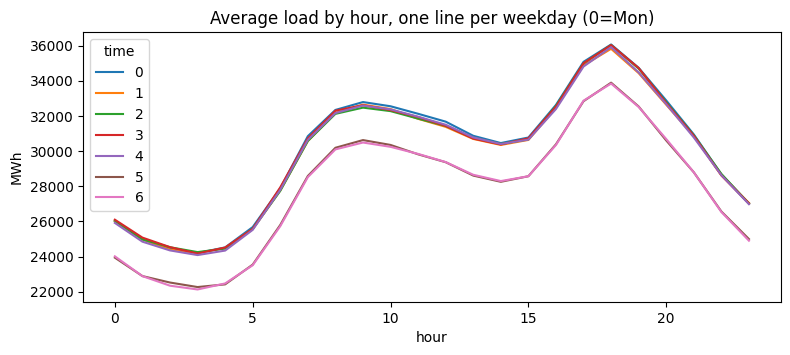

In [12]:
%matplotlib inline
ax = hourly.groupby([hourly.index.dayofweek, hourly.index.hour])["consumption_mwh"].mean().unstack(0).plot(
    figsize=(9, 3.5), title="Average load by hour, one line per weekday (0=Mon)")
ax.set_xlabel("hour"); ax.set_ylabel("MWh");

`pd.Grouper(freq=...)` groups a time index into calendar bins (monthly `"MS"`, weekly `"W"`), and combines with other keys — something `resample` cannot do.

In [13]:
monthly = hourly.groupby(pd.Grouper(freq="MS")).agg(
    load_mean=("consumption_mwh", "mean"),
    price_mean=("price_eur_mwh", "mean"),
    price_max=("price_eur_mwh", "max"),
    n_hours=("consumption_mwh", "size"),
).round(1)
monthly.head(6)

,load_mean,price_mean,price_max,n_hours
time,,,,
2022-01-01 00:00:00+00:00,32486.4,103.4,320.8,744
2022-02-01 00:00:00+00:00,31667.8,101.2,330.0,672
2022-03-01 00:00:00+00:00,31312.2,98.1,234.8,744
2022-04-01 00:00:00+00:00,28798.9,81.4,193.5,720
2022-05-01 00:00:00+00:00,27904.3,96.3,225.2,744
2022-06-01 00:00:00+00:00,27275.8,102.1,298.4,720


**Interview check:** *"Why does `n_hours` differ between months?"* — 28/30/31-day months × 24. If a month showed 720 where you expected 744, you have missing hours. Row counts per group are the cheapest sanity check there is.

## 7. Categoricals and `observed`

With `category` dtype, `groupby` includes **every category level**, including empty ones, unless `observed=True`. Pandas now warns if you do not say which you want; be explicit.

In [14]:
meters["tariff_cat"] = meters["tariff"].astype("category").cat.add_categories(["Prepay"])
print(meters.groupby("tariff_cat", observed=False).size().to_dict())
print(meters.groupby("tariff_cat", observed=True).size().to_dict())

{'Fixed': 143, 'TOU': 50, 'Variable': 94, 'Prepay': 0}
{'Fixed': 143, 'TOU': 50, 'Variable': 94}


## 8. `groupby().apply` — last resort

`apply` runs arbitrary Python per group. It is slow and the return shape depends on what the function returns (scalar → Series, Series → DataFrame, DataFrame → concatenated). Prefer `agg` / `transform`; if you need `apply`, return a Series with named entries.

In [15]:
def per_meter_stats(d):
    return pd.Series({"days": len(d), "kwh_total": d["kwh"].sum(), "kwh_cv": d["kwh"].std() / d["kwh"].mean()})

stats = readings.groupby("meter_id").apply(per_meter_stats, include_groups=False)
stats.head(3).round(3)

,days,kwh_total,kwh_cv
meter_id,,,
M100000,359.0,21939.204,0.389
M100001,358.0,2336.996,0.370
M100002,359.0,3639.039,0.362


In [16]:
%timeit readings.groupby("meter_id").apply(lambda d: d["kwh"].sum(), include_groups=False)

27.5 ms ± 160 µs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [17]:
%timeit readings.groupby("meter_id")["kwh"].sum()

4.68 ms ± 63.8 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


## 9. `pivot_table` — two keys into a grid

`pivot_table(values, index, columns, aggfunc)` aggregates duplicates, so it is safe. `margins=True` adds row/column totals (with the same `aggfunc`). The hour × weekday table below is the numeric version of the plot above.

In [18]:
grid = pd.pivot_table(
    hourly.assign(hour=hourly.index.hour, dow=hourly.index.dayofweek),
    values="consumption_mwh", index="hour", columns="dow", aggfunc="mean", margins=True,
).round(0)
grid.iloc[list(range(0, 24, 3)) + [24]]

dow,0,1,2,3,4,5,6,All
hour,,,,,,,,
0,26013.0,26019.0,26047.0,26097.0,25913.0,23937.0,24014.0,25430.0
3,24204.0,24189.0,24254.0,24173.0,24085.0,22266.0,22129.0,23610.0
6,27883.0,27759.0,27737.0,27937.0,27793.0,25798.0,25730.0,27230.0
9,32786.0,32641.0,32469.0,32606.0,32588.0,30625.0,30485.0,32025.0
12,31672.0,31377.0,31431.0,31438.0,31497.0,29366.0,29374.0,30875.0
15,30770.0,30633.0,30668.0,30726.0,30650.0,28569.0,28568.0,30079.0
18,36061.0,35814.0,36026.0,36027.0,35910.0,33889.0,33839.0,35363.0
21,30946.0,30847.0,30888.0,30871.0,30773.0,28792.0,28791.0,30268.0
All,30006.0,29866.0,29905.0,29940.0,29854.0,27847.0,27817.0,29315.0


## 10. `pivot` vs `pivot_table`

`pivot` **does not aggregate** — it errors if any (index, column) pair appears more than once. That error is useful: it tells you your key is not unique.

In [19]:
small = readings[readings["meter_id"].isin(["M100000", "M100001"])]
wide = small.pivot(index="date", columns="meter_id", values="kwh")
print(wide.shape)
print(wide.head(3))

dup = pd.concat([small, small.head(1)])
try:
    dup.pivot(index="date", columns="meter_id", values="kwh")
except ValueError as e:
    print("\npivot on duplicate keys ->", str(e)[:70])

(365, 2)
meter_id    M100000  M100001
date                        
2023-01-01   96.882   10.676
2023-01-02  111.294    5.849
2023-01-03   64.984    8.639

pivot on duplicate keys -> Index contains duplicate entries, cannot reshape


## 11. `melt` — wide back to long

Long format (one value per row) is what `groupby`, plotting libraries and models want. `melt` unpivots columns into `variable` / `value` pairs.

In [20]:
long_again = wide.reset_index().melt(id_vars="date", var_name="meter_id", value_name="kwh")
print(long_again.shape)
long_again.head(3)

(730, 3)


,date,meter_id,kwh
0,2023-01-01,M100000,96.882
1,2023-01-02,M100000,111.294
2,2023-01-03,M100000,64.984


## 12. `stack` / `unstack`

`unstack()` moves the inner index level into columns (long → wide); `stack()` does the reverse. They are the MultiIndex equivalent of pivot / melt.

In [21]:
mi = meters.groupby(["region", "customer_type"])["annual_kwh_estimate"].mean().round(0)
wide_mi = mi.unstack("customer_type")
print(wide_mi)
print("\nback to long:", wide_mi.stack().shape)

customer_type  residential      sme
region                             
London              3311.0  24201.0
Midlands            3179.0  23481.0
North               2942.0  27397.0
Scotland            2990.0  25021.0
Wales               3264.0  23909.0

back to long: (10,)


## 13. `crosstab` — counts of two categoricals

`pd.crosstab(a, b)` is a frequency table; `normalize="index"` gives row percentages.

In [22]:
print(pd.crosstab(meters["region"], meters["tariff"], margins=True))
pd.crosstab(meters["region"], meters["tariff"], normalize="index").round(2)

tariff    Fixed  TOU  Variable  All
region                             
London       47   16        30   93
Midlands     15    9        17   41
North        34   12        19   65
Scotland     30    8        17   55
Wales        17    5        11   33
All         143   50        94  287


tariff,Fixed,TOU,Variable
region,,,
London,0.51,0.17,0.32
Midlands,0.37,0.22,0.41
North,0.52,0.18,0.29
Scotland,0.55,0.15,0.31
Wales,0.52,0.15,0.33


## 14. Cumulative operations within a group

`groupby(...).cumsum()` / `cumcount()` respect group boundaries. Requires the frame to be sorted within each group first.

In [23]:
r = readings.sort_values(["meter_id", "date"]).copy()
r["kwh_cum"] = r.groupby("meter_id")["kwh"].cumsum()
r["day_no"] = r.groupby("meter_id").cumcount() + 1
r[r["meter_id"] == "M100000"].head(3)

,meter_id,date,kwh,kwh_cum,day_no
0,M100000,2023-01-01,96.882,96.882,1
1,M100000,2023-01-02,111.294,208.176,2
2,M100000,2023-01-03,64.984,273.160,3


## 15. `first` / `last` / `nth`

`first()` / `last()` return the first/last **non-null** value per column; `nth(k)` returns the k-th row regardless of NaN. Sort before you rely on the order.

In [24]:
g = r.groupby("meter_id")
pd.DataFrame({
    "first_date": g["date"].first(),
    "last_date": g["date"].last(),
    "second_row_kwh": g.nth(1).set_index("meter_id")["kwh"],
}).head(3)

,first_date,last_date,second_row_kwh
meter_id,,,
M100000,2023-01-01,2023-12-31,111.294
M100001,2023-01-01,2023-12-31,5.849
M100002,2023-01-01,2023-12-31,11.918


## 16. Rolling within groups

`groupby(key)[col].rolling(w)` computes a window **per group** without leaking across meters. The result has a `(key, original_index)` MultiIndex — `droplevel(0)` aligns it back to the frame. Note the `shift(1)` inside: the 7-day mean ending *yesterday*, so it never contains today's value.

In [25]:
r["kwh_mean7_prev"] = (
    r.groupby("meter_id")["kwh"]
     .transform(lambda s: s.shift(1).rolling(7, min_periods=7).mean())
)
# equivalent, showing the MultiIndex route
alt = r.groupby("meter_id")["kwh"].rolling(7, min_periods=7).mean()
print(alt.index.names)
r["kwh_mean7_incl_today"] = alt.droplevel(0)
r[r["meter_id"] == "M100000"][["date", "kwh", "kwh_mean7_prev", "kwh_mean7_incl_today"]].iloc[5:10]

['meter_id', None]


,date,kwh,kwh_mean7_prev,kwh_mean7_incl_today
5,2023-01-06,95.052,NaN,NaN
6,2023-01-07,86.008,NaN,105.711
7,2023-01-08,45.819,105.711,98.416
8,2023-01-09,66.566,98.416,92.027
9,2023-01-10,44.784,92.027,89.141


## 17. Sanity checks after groupby

An aggregation can drop rows (NaN keys, `dropna`), double count (bad merge before it) or silently include NaN as zero. Check:
1. group sizes sum to the row count,
2. totals are preserved,
3. the number of groups is what you expect.

In [26]:
by_region = readings.merge(meters[["meter_id", "region"]], on="meter_id", how="left")
agg = by_region.groupby("region", dropna=False)["kwh"].agg(["size", "sum"])
print(agg.round(0))
assert agg["size"].sum() == len(readings), "rows lost or gained"
assert np.isclose(agg["sum"].sum(), readings["kwh"].sum()), "total not preserved"
print("\nchecks passed; NaN region = readings whose meter_id is not in meters.csv:",
      by_region["region"].isna().sum())

           size       sum
region                   
London    35402  586808.0
Midlands  16114  286571.0
North     23613  368405.0
Scotland  20368  238355.0
Wales     11806  212232.0
NaN         200    3377.0

checks passed; NaN region = readings whose meter_id is not in meters.csv: 200


**Interview check:** *"You aggregated by region — where did the orphan meter go?"* Into the `NaN` group, which a default `groupby` would have dropped without a word. The `dropna=False` and the two asserts are what catch it.

## Quick reference

| want | use |
|---|---|
| one number per group | `groupby(k)[c].agg(f)` |
| several, flat names | `groupby(k).agg(name=(c, f), ...)` |
| rows per group | `size()` (not `count()`) |
| group stat on every row | `groupby(k)[c].transform(f)` |
| keep whole groups | `groupby(k).filter(f)` |
| calendar bins + other keys | `groupby([pd.Grouper(freq="MS"), k])` |
| grid with aggregation | `pivot_table(..., aggfunc=)` |
| grid, keys must be unique | `pivot` |
| wide → long | `melt`, `stack` |
| long → wide | `unstack` |
| counts of two categoricals | `pd.crosstab` |
| window per group | `groupby(k)[c].transform(lambda s: s.shift(1).rolling(w).mean())` |